# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [141]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [142]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [143]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі ПІСЛЯ, викликаючи `set_seed()`. Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [144]:
numbers = list(range(10)) # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) і random.shuffle(numbers)
print("- До set_seed()")
print("Випадкове число I:", random.randint(1, 100))
random.shuffle(numbers)
print("Перестановка I:", numbers)

print("Випадкове число II:", random.randint(1, 100))
random.shuffle(numbers)
print("Перестановка II:", numbers)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ
# окремим генеруванням, не один раз на обидва
print("\n- Після set_seed()")

set_seed()
print("Seed зафіксовано:", SEED)
print("Число I:", random.randint(1, 100))
random.shuffle(numbers)
print("Перестановка I:", numbers)

set_seed()
print("Число II:", random.randint(1, 100))
random.shuffle(numbers)
print("Перестановка II:", numbers)

- До set_seed()
Випадкове число I: 82
Перестановка I: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Випадкове число II: 76
Перестановка II: [5, 8, 2, 1, 6, 3, 4, 0, 7, 9]

- Після set_seed()
Seed зафіксовано: 42
Число I: 82
Перестановка I: [0, 1, 2, 7, 3, 4, 9, 6, 5, 8]
Число II: 82
Перестановка II: [6, 7, 2, 5, 4, 9, 8, 3, 0, 1]


Випадкові значення насправді є псевдовипадковими.

До виклику `set_seed()` результати генерації не зберігають конкретне зерно між перезапусками, тому під час виконання `random.randint()` отримуємо різні числа, а `random.shuffle()` створює різні перестановки списку.

Після виклику `set_seed()` генератор випадкових чисел починає повертати значення на основі певного зерна, тому значення `Число I` і `Число II` будуть повторюватися між запусками, так само як `Перестановка I` і `Перестановка II`.

Явно задаючи зерно бачимо, що випадковість може бути відтворюваною та передбачуваною.


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [145]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [146]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [147]:
# TODO: zeros_arr = np.zeros((3, 4))
# TODO: sevens_arr = np.full((3, 4), 7)
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [148]:
# TODO: arange_arr = np.arange(0, 20, 2)
# TODO: linspace_arr = np.linspace(0, 1, 5)
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [149]:
# TODO: identity = np.eye(4)
# TODO: random_ints = np.random.randint(0, 10, size=(3, 3))
identity = np.eye(4)
random_ints = np.random.randint(0, 10, (3, 3))

print(identity)
print(random_ints)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [150]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [151]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3,4)
row_sums = matrix.sum(1)
col_sums = matrix.sum(0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [152]:
df = pd.DataFrame({
    "student": ["Артем", "Дмитро", "Петро", "Микола", "Тарас"],
    "score":   [100, 90, 80, 70, 60]
}) # додай тут дані для DataFrame

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням
top = df.query("score > 80").sort_values("score", ascending=False)
print(top)


  student  score
0   Артем    100
1  Дмитро     90


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [153]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"
def get_grade(score):
    if score >= 90:   return "A"
    elif score >= 75: return "B"
    else: return "C"

df["grade"] = df["score"].apply(get_grade)
print(df)


  student  score grade
0   Артем    100     A
1  Дмитро     90     A
2   Петро     80     B
3  Микола     70     C
4   Тарас     60     C


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [154]:
# TODO: zeros_t = torch.zeros((2, 3))
# TODO: sevens_t = torch.full((2, 3), 7)
zeros_t = torch.zeros((2,3))
sevens_t = torch.full((2,3), 7)

print(zeros_t.shape, zeros_t.dtype)
print(sevens_t.shape, sevens_t.dtype)

torch.Size([2, 3]) torch.float32
torch.Size([2, 3]) torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [155]:
# TODO: arange_t = torch.arange(0, 20, 2)
# TODO: linspace_t = torch.linspace(0, 1, 5)
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [156]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list.shape, from_list.dtype, from_list.ndim)
print(random_t.shape, random_t.dtype, random_t.ndim)


torch.Size([2, 2]) torch.int64 2
torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [157]:
n = 5.0

# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

# надрукувати x.grad.item() і порівняти з 2 * n
grad = x.grad.item()

print(grad)
print(2 * n)
print(grad == 2 * n)

10.0
10.0
True


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [158]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
#   loss = (x - 3) ** 2 + 5
#   loss.backward()
#   під torch.no_grad(): x -= lr * x.grad
#   x.grad.zero_()

for _ in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad

    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

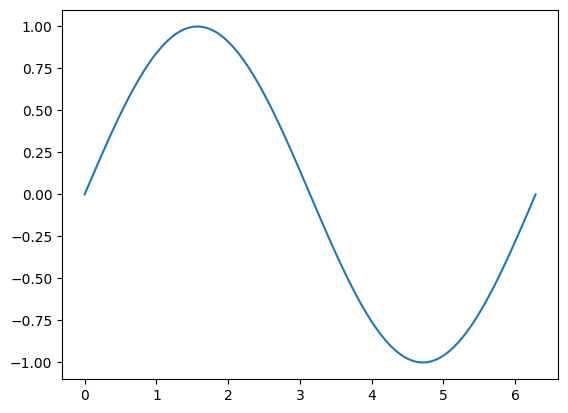

In [159]:
# TODO: xs = np.linspace(0, 2*np.pi, 100), plt.plot(xs, np.sin(xs)), plt.show()

xs = np.linspace(0, 2*np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.show()

**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

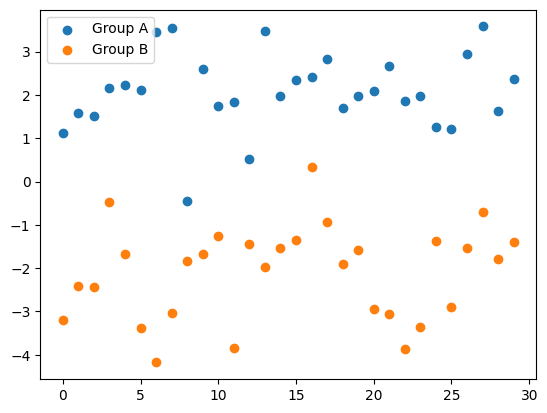

In [160]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()

plt.scatter(range(len(group_a)), group_a, color="C0", label="Group A")
plt.scatter(range(len(group_b)), group_b, color="C1", label="Group B")

plt.legend()
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [161]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

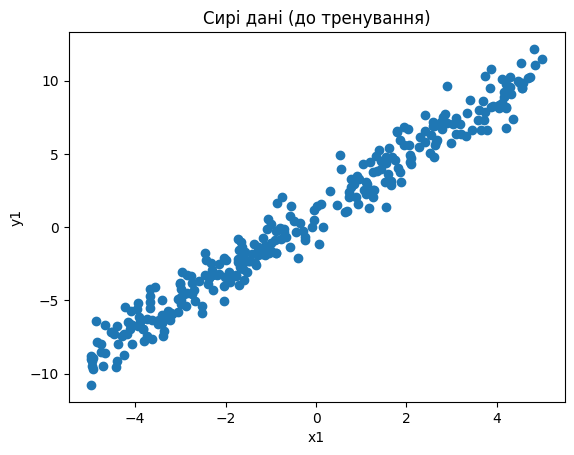

In [162]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"

plt.scatter(x1, y1)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [163]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...

randperm = torch.randperm(TASK1_N)

rand_x1 = x1[randperm]
rand_y1 = y1[randperm]

n_train = int(0.70 * TASK1_N)
n_val = int(0.15 * TASK1_N)

x_train1 = rand_x1[:n_train]
y_train1 = rand_y1[:n_train]

x_val1 = rand_x1[n_train:n_train + n_val]
y_val1 = rand_y1[n_train:n_train + n_val]

x_test1 = rand_x1[n_train + n_val:]
y_test1 = rand_y1[n_train + n_val:]


print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [164]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


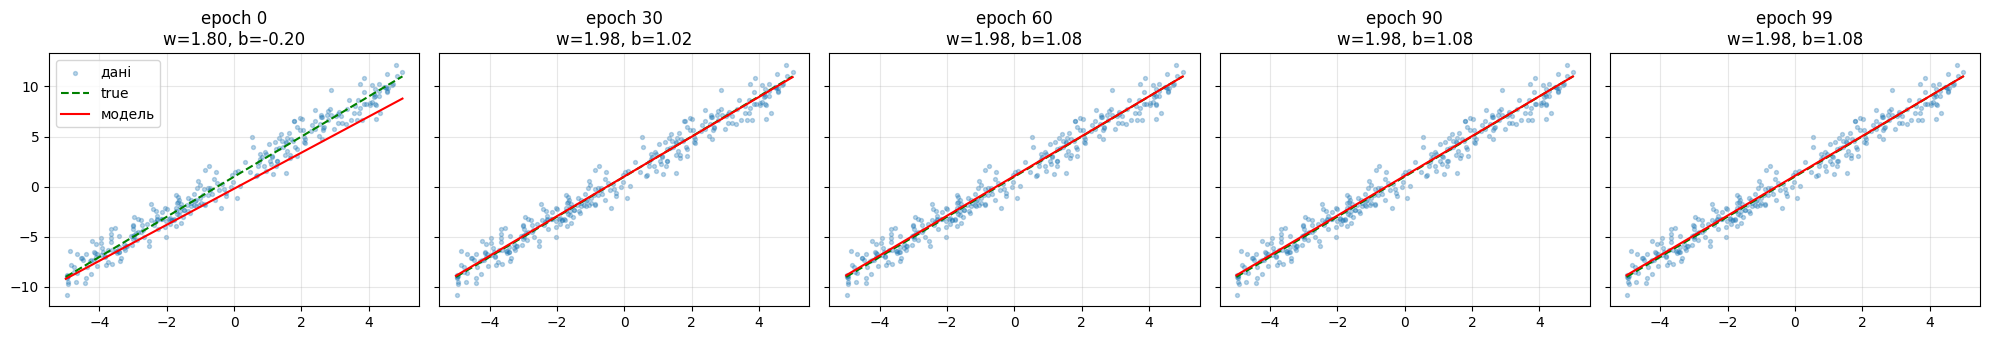

In [165]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

### Сценарій - Unity DOTS
Розглянемо сценарій роботи з Unity DOTS. Припустимо, що існує підсцена з системою, яка на основному потоці обробляє певну кількість сутностей X за певний час Y. Вважатимемо, що сама система запускається за 1.2 мкс, тоді як кожна додаткова сутність додає в середньому 0.5 мкс до загального часу обробки.

У такому випадку w = 0.5, b = 1.2.

Закладемо лінійну залежність y = wx + b:

y = 0.5 * x + 1.2.

Продуктивність Unity DOTS залежить від багатьох факторів, тому доцільно додати шум до даних, щоб змоделювати більш реалістичні умови вимірювання, зокрема оверхед рушія, роботу збирача сміття та активність профайлерів.

Загалом, 0.5 мкс можна вважати реалістичним показником, оскільки обробка однієї сутності може передбачати додаткові операції: ініціалізацію масивів, запити необхідних компонентів чи синхронізацію з іншими системами. У звичайних умовах ці операції виконуються дуже швидко, однак під час роботи з десятками тисяч таких сутностей - вартість операцій швидко накопичується.

#### Генерація даних

In [166]:
set_seed(42)

DOTS_TRUE_W = 0.5
DOTS_TRUE_B = 1.2
DOTS_N = 1000

x1 = torch.empty(DOTS_N, 1).uniform_(0, 10)
noise = 0.5 * torch.randn(DOTS_N, 1)
y1 = DOTS_TRUE_W * x1 + DOTS_TRUE_B + noise

#### Збереження даних

In [167]:
df = pd.DataFrame({
    'entities': x1.flatten().numpy(),
    'time_ms': y1.flatten().numpy()
})

dataset_path = os.path.join(ARTIFACT_DIR, "dataset.csv")
df.to_csv(dataset_path, index=False)

print("Датасет збережено:", dataset_path)

Датасет збережено: /content/drive/MyDrive/ai_systems/lab1/dataset.csv


#### Спліт даних

In [168]:
set_seed(42)

randperm = torch.randperm(DOTS_N)

rand_x1 = x1[randperm]
rand_y1 = y1[randperm]

n_train = int(0.70 * DOTS_N)
n_val = int(0.15 * DOTS_N)

x_train1 = rand_x1[:n_train]
y_train1 = rand_y1[:n_train]

x_val1 = rand_x1[n_train:n_train + n_val]
y_val1 = rand_y1[n_train:n_train + n_val]

x_test1 = rand_x1[n_train + n_val:]
y_test1 = rand_y1[n_train + n_val:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")

train/val/test: 700/150/150


#### Тренування моделі

In [169]:
set_seed(42)

def train_step(model, optimizer, loss_fn, x, y):
    model.train()
    optimizer.zero_grad()
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    loss.backward()
    optimizer.step()
    return loss.item()

def train_model(model, optimizer, loss_fn, x_train, y_train, epochs=100, on_epoch=None):
    history = {'loss': []}
    for epoch in range(epochs):
        loss = train_step(model, optimizer, loss_fn, x_train, y_train)
        history['loss'].append(loss)
        if on_epoch:
            on_epoch(epoch, epochs, model, loss)
    return history

snapshots = []
x_line = torch.linspace(0, 10, 100).unsqueeze(1)

def snapshot_callback(epoch, total_epochs, model, loss):
    if epoch % 100 == 0 or epoch == total_epochs - 1:
        with torch.no_grad():
            model.eval()
            y_line_pred = model(x_line)
            w = model.weight.item()
            b = model.bias.item()
            snapshots.append((epoch, w, b, y_line_pred))

        print(f"epoch {epoch:4d} ; loss={loss:.6f} ; w={w:.4f} (true {DOTS_TRUE_W}) ; b={b:.4f} (true {DOTS_TRUE_B})")

dots_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(dots_model.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

history = train_model(
    model=dots_model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    x_train=x_train1,
    y_train=y_train1,
    epochs=500,
    on_epoch=snapshot_callback
)

epoch    0 ; loss=1.817515 ; w=0.6236 (true 0.5) ; b=0.8109 (true 1.2)
epoch  100 ; loss=0.280929 ; w=0.5302 (true 0.5) ; b=0.9600 (true 1.2)
epoch  200 ; loss=0.271522 ; w=0.5159 (true 0.5) ; b=1.0544 (true 1.2)
epoch  300 ; loss=0.268227 ; w=0.5075 (true 0.5) ; b=1.1104 (true 1.2)
epoch  400 ; loss=0.267073 ; w=0.5025 (true 0.5) ; b=1.1434 (true 1.2)
epoch  499 ; loss=0.266671 ; w=0.4996 (true 0.5) ; b=1.1629 (true 1.2)


#### Перевірка моделі

In [170]:
def test_model(model, loss_fn, x_test, y_test):
    with torch.no_grad():
        y_pred = model(x_test)
        loss = loss_fn(y_pred, y_test)
    test_loss = loss.item()
    print(f"Test Loss: {test_loss:.6f}")

test_model(dots_model, loss_fn, x_test1, y_test1)

Test Loss: 0.260402


#### Візуалізація моделі

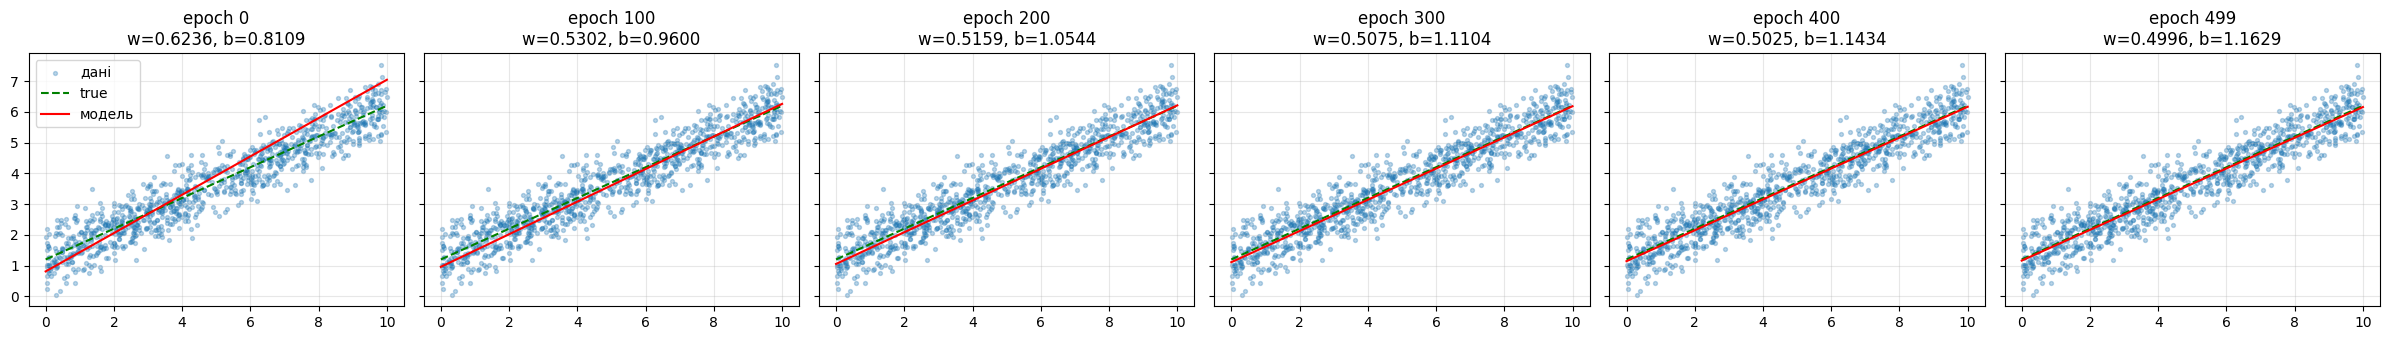

In [171]:
with torch.no_grad():
    y_line_true = DOTS_TRUE_W * x_line + DOTS_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.4f}, b={b:.4f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [172]:
model_path = os.path.join(ARTIFACT_DIR, "model.pt")

torch.save(dots_model.state_dict(), model_path)

print("Модель збережено:", model_path)

Модель збережено: /content/drive/MyDrive/ai_systems/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [173]:
!pip install -q gradio
import gradio as gr

model_path = os.path.join(ARTIFACT_DIR, "model.pt")

model = torch.nn.Linear(in_features=1, out_features=1)
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

def predict(x):
    x_tensor = torch.tensor([[float(x)]], dtype=torch.float32)
    with torch.no_grad():
        y_pred = model(x_tensor)
    return y_pred.item()

demo = gr.Interface(
    fn=predict,
    inputs=gr.Number(label="Кількість сутностей", value=5),
    outputs=gr.Number(label="Час обробки, мкс"),
    title="Unity DOTS: Entity Linear Regression Model"
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://67476193711945ad2e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```